# Independent Component Analysis (ICA) untuk Klasifikasi Kualitas Wine

**Dataset:** Wine Quality Dataset (UCI / Kaggle)

**Tujuan:** Menerapkan ICA sebagai teknik ekstraksi fitur dan membandingkan performa klasifikasi Random Forest dengan dan tanpa ICA.

**Metode:**
1. Exploratory Data Analysis (EDA)
2. Preprocessing: StandardScaler
3. Feature Extraction: FastICA
4. Classification: Random Forest
5. Evaluasi & Perbandingan

---
## 1. Import Library

In [1]:
# Manipulasi data dan komputasi numerik
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing dan feature extraction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA

# Model dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Konfigurasi visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


---
## 2. Load Dataset

In [2]:
# Load dataset wine quality (red + white)
file_path = 'wine-quality-white-and-red.csv'
df = pd.read_csv(file_path)

# Tampilkan informasi awal dataset
print(f'Dataset berhasil dimuat.')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'Nama kolom: {list(df.columns)}')
df.head()

Dataset berhasil dimuat.
Jumlah baris: 6497
Jumlah kolom: 13
Nama kolom: ['type', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Informasi Dataset

In [3]:
# Informasi tipe data dan non-null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [4]:
# Statistik deskriptif setiap fitur
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [5]:
# Cek missing values
missing_values = df.isnull().sum()
print('Jumlah missing values per kolom:')
print(missing_values[missing_values > 0] if missing_values.any() else 'Tidak ada missing values.')

Jumlah missing values per kolom:
Tidak ada missing values.


In [6]:
# Cek duplicate data
duplicate_count = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicate_count}')

# Hapus duplikat jika ada
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Data duplikat telah dihapus. Sisa baris: {df.shape[0]}')

Jumlah data duplikat: 1177
Data duplikat telah dihapus. Sisa baris: 5320


### 3.2 Distribusi Target (Quality)

C:\Users\laila\AppData\Local\Temp\ipykernel_13652\3851710139.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='quality', palette='viridis')


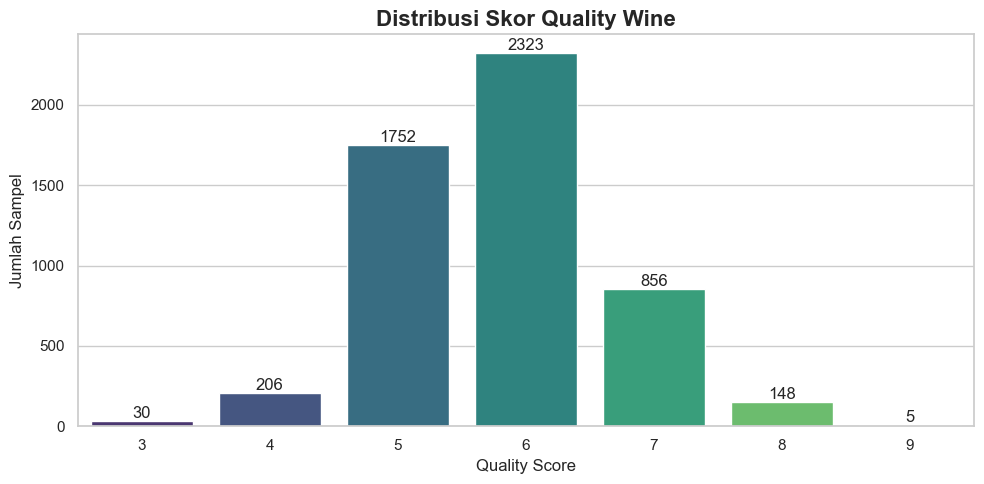

Distribusi Quality:
  Quality 3: 30 sampel (0.56%)
  Quality 4: 206 sampel (3.87%)
  Quality 5: 1752 sampel (32.93%)
  Quality 6: 2323 sampel (43.67%)
  Quality 7: 856 sampel (16.09%)
  Quality 8: 148 sampel (2.78%)
  Quality 9: 5 sampel (0.09%)


In [7]:
# Visualisasi distribusi target quality
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='quality', palette='viridis')
for p in ax.containers:
    ax.bar_label(p, fmt='%d')
plt.title('Distribusi Skor Quality Wine', fontsize=16, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()

# Tampilkan distribusi dalam persen
quality_dist = df['quality'].value_counts().sort_index()
print('Distribusi Quality:')
for q, count in quality_dist.items():
    print(f'  Quality {q}: {count} sampel ({count/len(df)*100:.2f}%)')

### 3.3 Histogram Semua Fitur

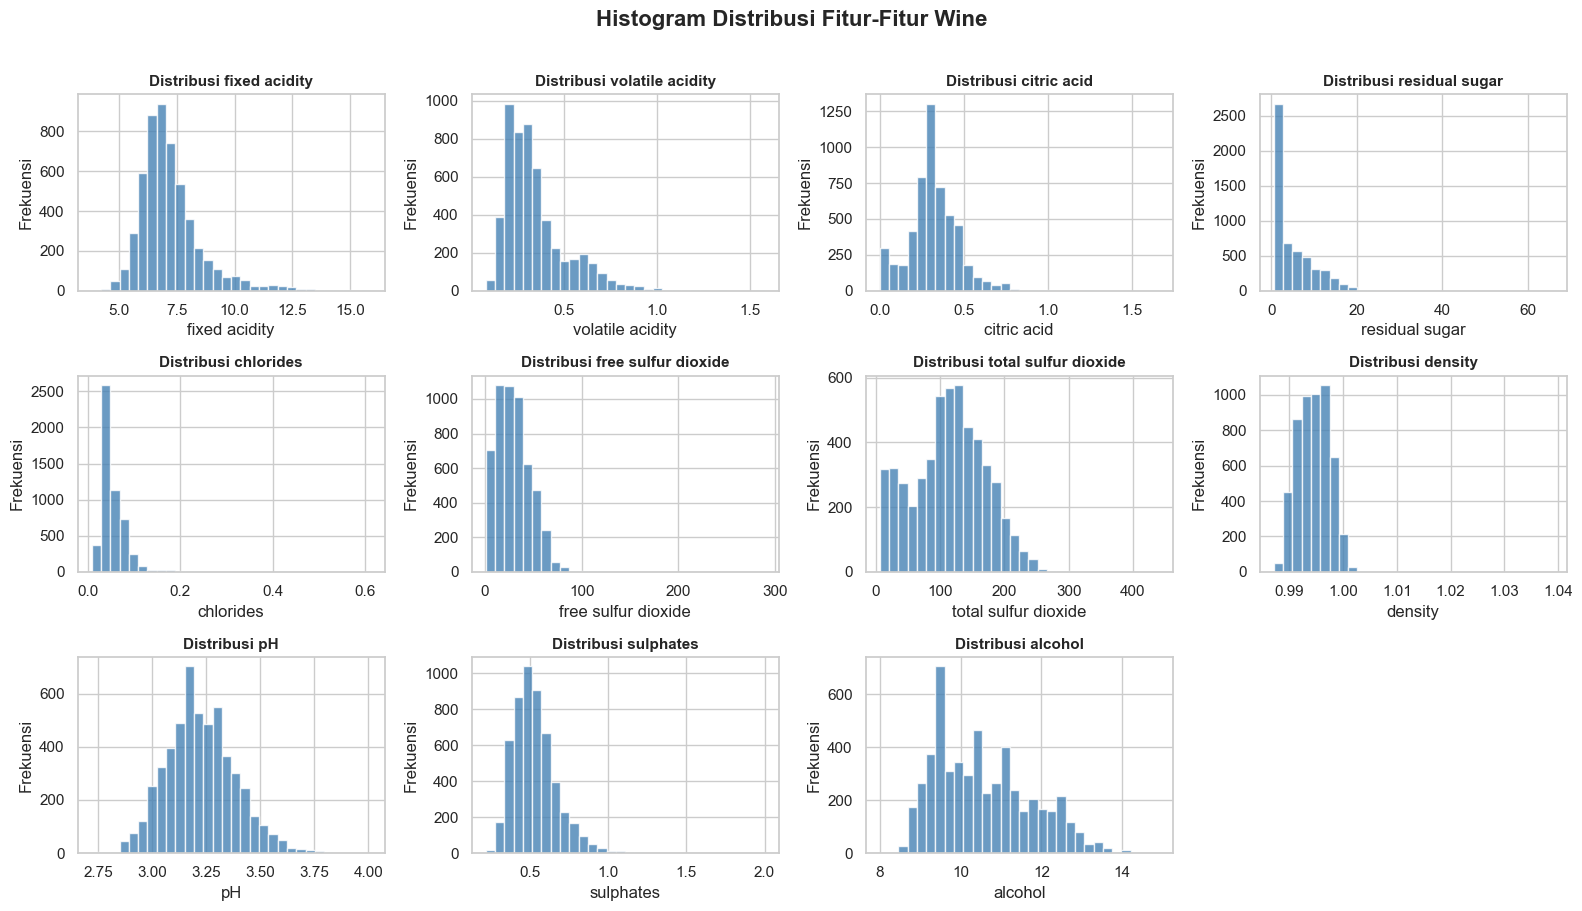

In [8]:
# Histogram untuk melihat distribusi setiap fitur numerik
numerical_columns = df.select_dtypes(include=[np.number]).columns.drop('quality')
n_cols = 4
n_rows = int(np.ceil(len(numerical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan axes yang tidak terpakai
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogram Distribusi Fitur-Fitur Wine', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Boxplot

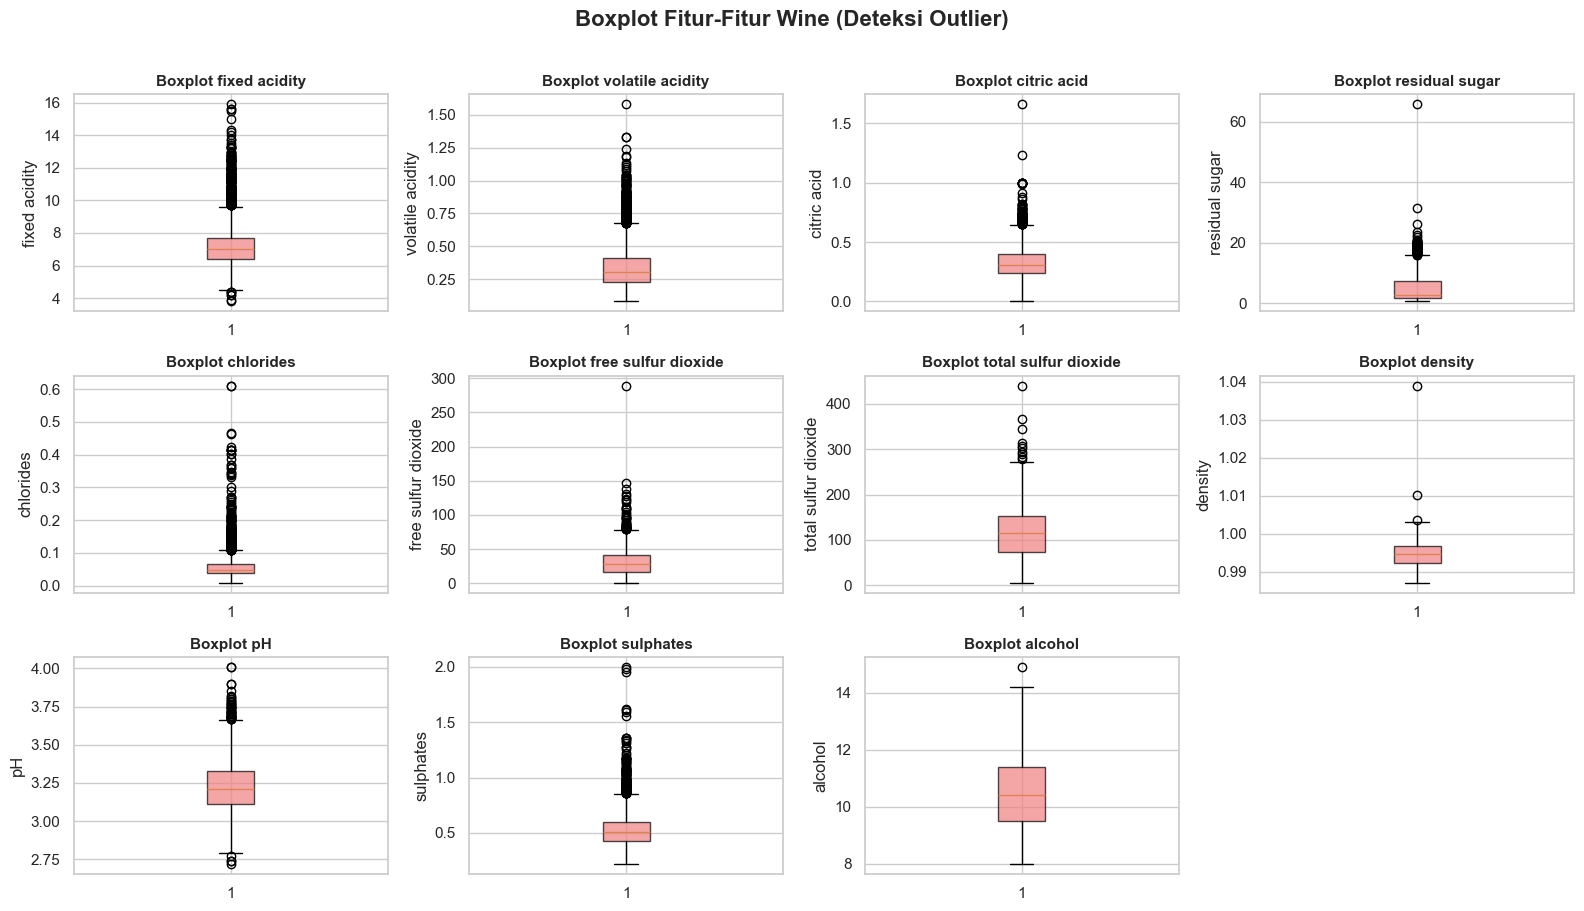

In [9]:
# Boxplot untuk mendeteksi outlier dan melihat sebaran data
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[i].set_title(f'Boxplot {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Fitur-Fitur Wine (Deteksi Outlier)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Heatmap Korelasi

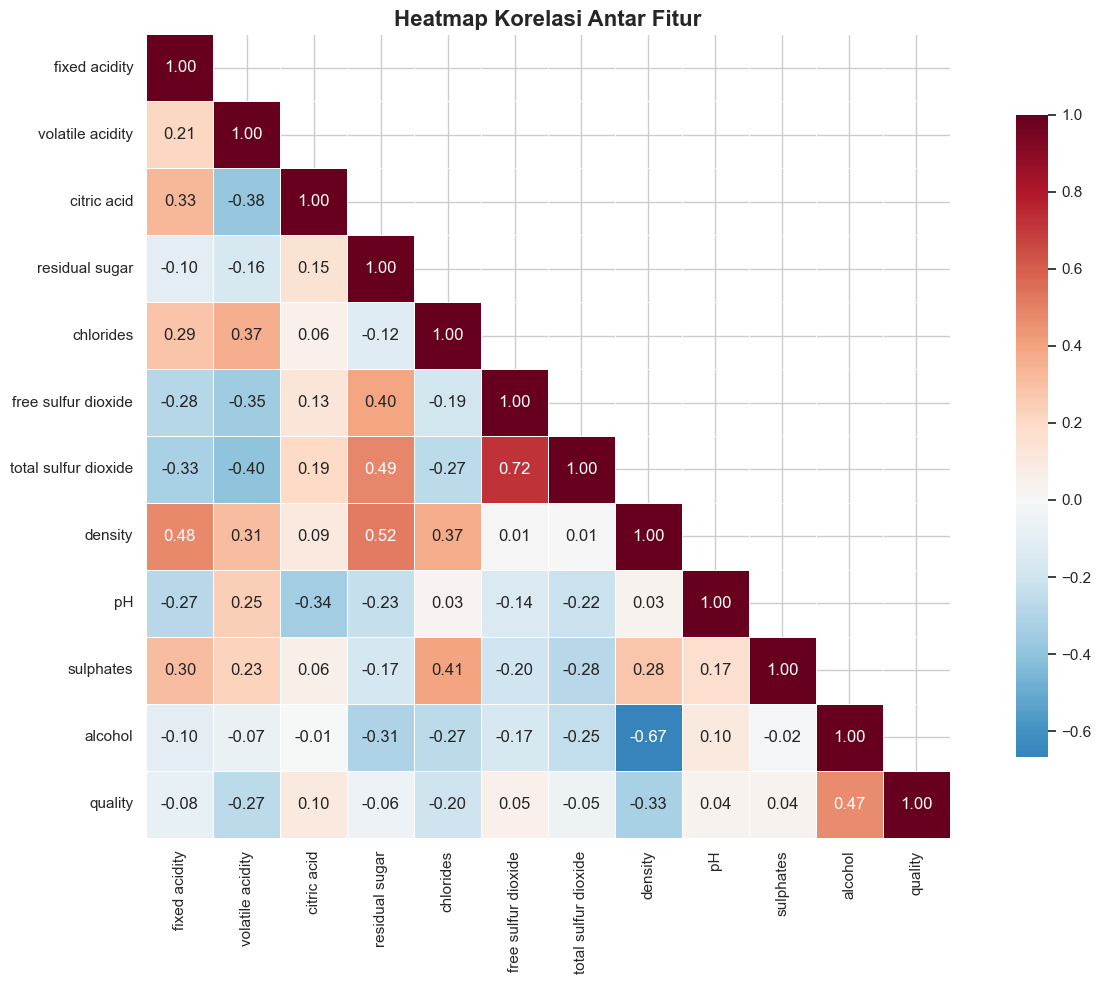

Korelasi fitur terhadap quality:
  alcohol                  : +0.4694
  citric acid              : +0.0980
  free sulfur dioxide      : +0.0540
  sulphates                : +0.0419
  pH                       : +0.0397
  total sulfur dioxide     : -0.0503
  residual sugar           : -0.0568
  fixed acidity            : -0.0801
  chlorides                : -0.2021
  volatile acidity         : -0.2652
  density                  : -0.3264


In [10]:
# Heatmap korelasi antar fitur numerik
plt.figure(figsize=(14, 10))
correlation_matrix = df[numerical_columns.tolist() + ['quality']].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Fitur dengan korelasi tertinggi terhadap quality
print('Korelasi fitur terhadap quality:')
corr_with_target = correlation_matrix['quality'].drop('quality').sort_values(ascending=False)
for col, val in corr_with_target.items():
    print(f'  {col:25s}: {val:+.4f}')

---
## 4. Data Preprocessing

### 4.1 Pisahkan Fitur dan Target

Kolom `type` (white/red) adalah kategorikal dan tidak relevan untuk analisis numerik ICA, sehingga akan di-drop.

Target `quality` akan di-binerisasi:
- **Good (1):** quality >= 7
- **Not Good (0):** quality < 7

Alasan binerisasi: distribusi quality tidak seimbang (lihat EDA). Dengan binerisasi, kita mendapatkan target yang lebih jelas untuk klasifikasi.

In [11]:
# Drop kolom 'type' (kategorikal)
df_processed = df.drop(columns=['type'])

# Pisahkan fitur (X) dan target (y)
X = df_processed.drop(columns=['quality'])
y = df_processed['quality'].copy()

# Binerisasi target: quality >= 7 -> Good (1), else -> Not Good (0)
y_binary = (y >= 7).astype(int)

print(f'Jumlah fitur: {X.shape[1]}')
print(f'Jumlah sampel: {X.shape[0]}')
print(f'Distribusi target setelah binerisasi:')
print(f'  Good (1): {(y_binary == 1).sum()} sampel ({(y_binary == 1).sum()/len(y_binary)*100:.2f}%)')
print(f'  Not Good (0): {(y_binary == 0).sum()} sampel ({(y_binary == 0).sum()/len(y_binary)*100:.2f}%)')

Jumlah fitur: 11
Jumlah sampel: 5320
Distribusi target setelah binerisasi:
  Good (1): 1009 sampel (18.97%)
  Not Good (0): 4311 sampel (81.03%)


### 4.2 StandardScaler

**Mengapa data harus distandarisasi sebelum ICA?**

1. **ICA sensitif terhadap skala:** ICA bekerja dengan memaksimalkan non-Gaussianity (kurtosis) dari komponen. Jika fitur memiliki skala yang berbeda (misalnya pH ~3 vs total sulfur dioxide ~100), fitur dengan skala besar akan mendominasi perhitungan.

2. **Centering (mean=0) diperlukan:** Algoritma FastICA mengasumsikan data memiliki mean nol. Langkah centering adalah prasyarat untuk estimasi ICA.

3. **Variance unity (std=1):** Dengan StandardScaler, setiap fitur memiliki kontribusi yang sama tanpa memandang skala aslinya, sehingga ICA dapat menemukan komponen independen yang sebenarnya.

In [12]:
# Terapkan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Konversi kembali ke DataFrame untuk kemudahan interpretasi
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Data setelah StandardScaler:')
print(f'Mean setiap fitur (mendekati 0): {np.mean(X_scaled, axis=0).round(6)}')
print(f'Std setiap fitur (mendekati 1): {np.std(X_scaled, axis=0).round(6)}')
print()
X_scaled_df.head()

Data setelah StandardScaler:
Mean setiap fitur (mendekati 0): [ 0. -0.  0.  0.  0.  0. -0.  0.  0. -0.  0.]
Std setiap fitur (mendekati 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.163070,-0.440639,0.282076,3.478304,-0.317143,0.840478,0.984535,2.180171,-1.400959,-0.556721,-1.475130
1,-0.693555,-0.262314,0.146154,-0.766370,-0.208624,-0.900765,0.315155,-0.180525,0.469784,-0.289571,-0.884822
2,0.670550,-0.381197,0.553919,0.411472,-0.181494,-0.002059,-0.301380,0.190441,0.220351,-0.623508,-0.378844
3,-0.011503,-0.678405,0.010232,0.767046,0.035544,0.952816,1.266380,0.359062,-0.216155,-0.890658,-0.547503
4,-0.769339,-0.143431,-1.077141,0.433695,-0.317143,-0.002059,0.385616,0.122993,-0.278513,-0.423146,-0.800493


---
## 5. Independent Component Analysis (ICA)

### 5.1 FastICA

**Apa itu ICA?**

Independent Component Analysis (ICA) adalah teknik statistik yang memisahkan sinyal multivariat menjadi komponen-komponen yang saling independen secara statistik. Berbeda dengan PCA yang mencari komponen ortogonal dengan varians maksimum, ICA mencari komponen yang independen berdasarkan non-Gaussianity.

**Jumlah komponen: 6**

Alasan pemilihan:
- Terdapat 11 fitur numerik yang digunakan.
- 6 komponen (sekitar setengah dari jumlah fitur) memberikan keseimbangan antara reduksi dimensi dan retensi informasi.
- Dengan 6 komponen independen, kita tetap mempertahankan struktur data yang bermakna sambil mengurangi noise dan redundansi.
- Kurang dari 6 komponen berisiko kehilangan informasi penting; lebih dari 6 komponen mengurangi efektivitas reduksi dimensi.

In [13]:
# Tentukan jumlah komponen ICA
n_components = 6

# Inisialisasi dan aplikasi FastICA
ica = FastICA(n_components=n_components, random_state=42, max_iter=1000)
X_ica = ica.fit_transform(X_scaled)

# Konversi ke DataFrame
ica_columns = [f'IC{i+1}' for i in range(n_components)]
X_ica_df = pd.DataFrame(X_ica, columns=ica_columns)

print(f'Hasil transformasi ICA:')
print(f'Shape sebelum ICA: {X_scaled.shape}')
print(f'Shape setelah ICA: {X_ica.shape}')
print(f'Jumlah komponen: {n_components}')
print()
X_ica_df.head()

Hasil transformasi ICA:
Shape sebelum ICA: (5320, 11)
Shape setelah ICA: (5320, 6)
Jumlah komponen: 6



,IC1,IC2,IC3,IC4,IC5,IC6
0,1.554896,0.637071,-0.909920,-2.423709,-0.187227,0.977494
1,-0.088805,-1.218634,-0.113474,-0.150193,0.354330,-1.303683
2,0.616940,-0.413458,-0.445908,-0.315784,-0.522015,-0.557682
3,0.119199,0.011943,-0.754633,-0.797453,0.672442,0.045914
4,0.319594,0.063177,0.271880,-0.767614,0.886525,-0.408342


In [14]:
# Informasi tambahan tentang komponen ICA
print('Informasi Komponen ICA:')
print(f'Kurtosis setiap komponen (nilai tinggi = non-Gaussian):')
for i, col in enumerate(ica_columns):
    kurt = X_ica_df[col].kurtosis()
    print(f'  {col}: kurtosis = {kurt:.4f}')

print(f'\nKurtosis rata-rata: {X_ica_df.kurtosis().mean():.4f}')
print('(Semakin tinggi kurtosis, semakin non-Gaussian komponen tersebut)')

Informasi Komponen ICA:
Kurtosis setiap komponen (nilai tinggi = non-Gaussian):
  IC1: kurtosis = 34.4068
  IC2: kurtosis = 0.4274
  IC3: kurtosis = 1.4097
  IC4: kurtosis = -0.1161
  IC5: kurtosis = 3.3948
  IC6: kurtosis = 2.9424

Kurtosis rata-rata: 7.0775
(Semakin tinggi kurtosis, semakin non-Gaussian komponen tersebut)


### 5.2 Visualisasi Komponen ICA

C:\Users\laila\AppData\Local\Temp\ipykernel_13652\4230460035.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


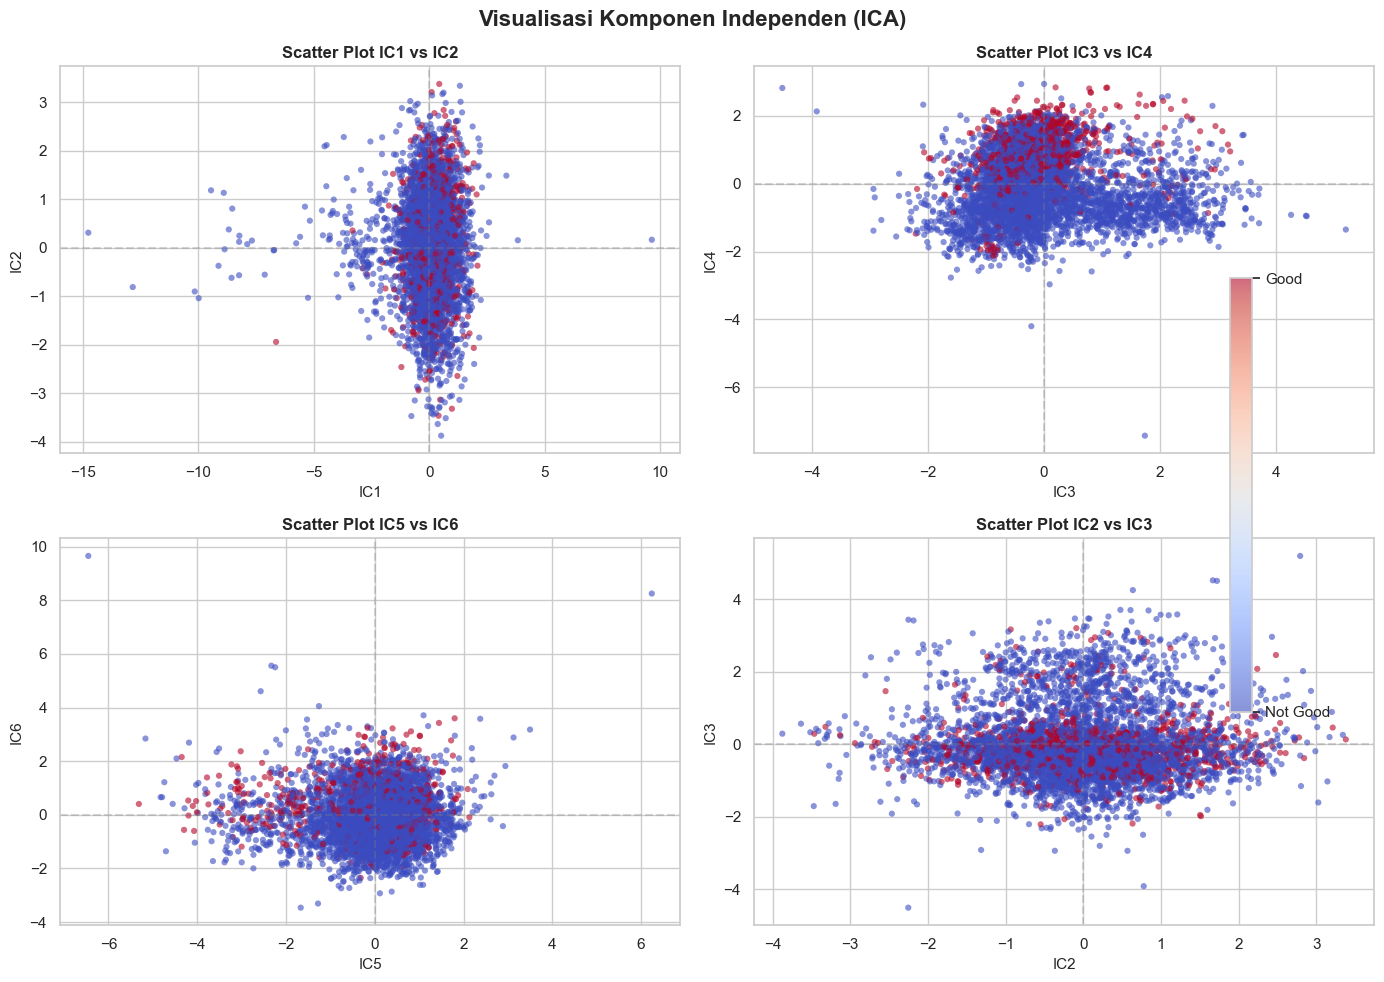

In [15]:
# Scatter plot 2D untuk melihat hubungan antar komponen ICA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot pasangan komponen
scatter_pairs = [('IC1', 'IC2'), ('IC3', 'IC4'), ('IC5', 'IC6'), ('IC2', 'IC3')]

for ax, (ic_x, ic_y) in zip(axes.flatten(), scatter_pairs):
    scatter = ax.scatter(
        X_ica_df[ic_x], X_ica_df[ic_y],
        c=y_binary, cmap='coolwarm', alpha=0.6, edgecolors='none', s=20
    )
    ax.set_xlabel(f'{ic_x}', fontsize=11)
    ax.set_ylabel(f'{ic_y}', fontsize=11)
    ax.set_title(f'Scatter Plot {ic_x} vs {ic_y}', fontsize=12, fontweight='bold')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.3)

# Legend global
cbar = fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Not Good', 'Good'])

plt.suptitle('Visualisasi Komponen Independen (ICA)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

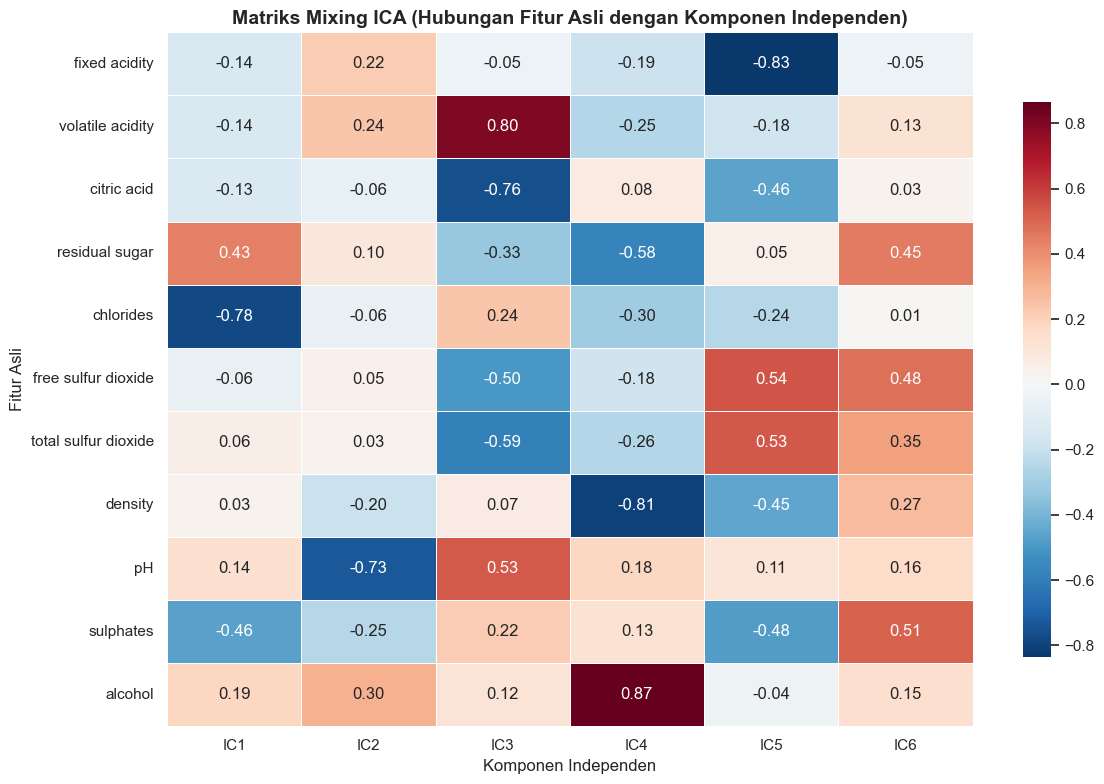

Interpretasi: Nilai absolut besar menunjukkan kontribusi kuat fitur tersebut terhadap komponen ICA.


In [16]:
# Matriks mixing (hubungan antara fitur asli dan komponen ICA)
mixing_matrix = pd.DataFrame(
    ica.mixing_,
    index=X.columns,
    columns=ica_columns
)

plt.figure(figsize=(12, 8))
sns.heatmap(mixing_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriks Mixing ICA (Hubungan Fitur Asli dengan Komponen Independen)',
          fontsize=14, fontweight='bold')
plt.xlabel('Komponen Independen')
plt.ylabel('Fitur Asli')
plt.tight_layout()
plt.show()

print('Interpretasi: Nilai absolut besar menunjukkan kontribusi kuat fitur tersebut terhadap komponen ICA.')

---
## 6. Split Dataset

Dataset dibagi menjadi training (80%) dan testing (20%) menggunakan `train_test_split`.

In [17]:
# Split data: 80% training, 20% testing
test_size = 0.2
random_state = 42

# Split untuk data NON-ICA (fitur asli)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary, test_size=test_size, random_state=random_state, stratify=y_binary
)

# Split untuk data ICA
X_train_ica, X_test_ica, y_train_ica, y_test_ica = train_test_split(
    X_ica, y_binary, test_size=test_size, random_state=random_state, stratify=y_binary
)

print('Split Dataset (80:20):')
print(f'  NON-ICA:')
print(f'    X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'    X_test:  {X_test.shape}, y_test: {y_test.shape}')
print(f'  ICA:')
print(f'    X_train_ica: {X_train_ica.shape}, y_train_ica: {y_train_ica.shape}')
print(f'    X_test_ica:  {X_test_ica.shape}, y_test_ica: {y_test_ica.shape}')
print()
print(f'Proporsi target di training:')
print(f'  Good: {y_train.sum()}/{len(y_train)} ({y_train.mean()*100:.2f}%)')
print(f'  Not Good: {(1-y_train).sum()}/{len(y_train)} {(1-y_train.mean())*100:.2f}%')

Split Dataset (80:20):
  NON-ICA:
    X_train: (4256, 11), y_train: (4256,)
    X_test:  (1064, 11), y_test: (1064,)
  ICA:
    X_train_ica: (4256, 6), y_train_ica: (4256,)
    X_test_ica:  (1064, 6), y_test_ica: (1064,)

Proporsi target di training:
  Good: 807/4256 (18.96%)
  Not Good: 3449/4256 81.04%


---
## 7. Klasifikasi dengan Random Forest

### Random Forest Classifier

Random Forest adalah ensemble method yang menggabungkan banyak decision tree untuk meningkatkan akurasi dan mengurangi overfitting.

In [18]:
# Fungsi evaluasi model
def evaluate_model(y_true, y_pred, model_name='Model'):
    """Menghitung metrik evaluasi klasifikasi."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f'=== {model_name} ===')
    print(f'Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')
    print(f'Precision: {precision:.4f} ({precision*100:.2f}%)')
    print(f'Recall   : {recall:.4f} ({recall*100:.2f}%)')
    print(f'F1-Score : {f1:.4f} ({f1*100:.2f}%)')
    print()
    print('Confusion Matrix:')
    print(f'              Predicted')
    print(f'              Not Good  Good')
    print(f'Actual Not Good  {cm[0,0]:5d}    {cm[0,1]:4d}')
    print(f'       Good      {cm[1,0]:5d}    {cm[1,1]:4d}')
    print()
    print('Classification Report:')
    print(classification_report(y_true, y_pred, target_names=['Not Good', 'Good'], zero_division=0))
    print('=' * 40)

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Confusion Matrix': cm
    }

### 7.1 Klasifikasi Tanpa ICA (Fitur Asli)

In [19]:
# Random Forest tanpa ICA
rf_no_ica = RandomForestClassifier(n_estimators=100, random_state=random_state)
rf_no_ica.fit(X_train, y_train)

# Prediksi
y_pred_no_ica = rf_no_ica.predict(X_test)

# Evaluasi
results_no_ica = evaluate_model(y_test, y_pred_no_ica, model_name='Random Forest Tanpa ICA')

=== Random Forest Tanpa ICA ===
Accuracy : 0.8477 (84.77%)
Precision: 0.6786 (67.86%)
Recall   : 0.3762 (37.62%)
F1-Score : 0.4841 (48.41%)

Confusion Matrix:
              Predicted
              Not Good  Good
Actual Not Good    826      36
       Good        126      76

Classification Report:
              precision    recall  f1-score   support

    Not Good       0.87      0.96      0.91       862
        Good       0.68      0.38      0.48       202

    accuracy                           0.85      1064
   macro avg       0.77      0.67      0.70      1064
weighted avg       0.83      0.85      0.83      1064



### 7.2 Klasifikasi Dengan ICA

In [20]:
# Random Forest dengan ICA
rf_ica = RandomForestClassifier(n_estimators=100, random_state=random_state)
rf_ica.fit(X_train_ica, y_train_ica)

# Prediksi
y_pred_ica = rf_ica.predict(X_test_ica)

# Evaluasi
results_ica = evaluate_model(y_test_ica, y_pred_ica, model_name='Random Forest dengan ICA')

=== Random Forest dengan ICA ===
Accuracy : 0.8252 (82.52%)
Precision: 0.5667 (56.67%)
Recall   : 0.3366 (33.66%)
F1-Score : 0.4224 (42.24%)

Confusion Matrix:
              Predicted
              Not Good  Good
Actual Not Good    810      52
       Good        134      68

Classification Report:
              precision    recall  f1-score   support

    Not Good       0.86      0.94      0.90       862
        Good       0.57      0.34      0.42       202

    accuracy                           0.83      1064
   macro avg       0.71      0.64      0.66      1064
weighted avg       0.80      0.83      0.81      1064



---
## 8. Perbandingan Performa

Perbandingan antara model **Tanpa ICA** dan **Dengan ICA** dalam bentuk tabel.

In [21]:
# Buat tabel perbandingan
comparison_df = pd.DataFrame([
    {
        'Metrik': 'Accuracy',
        'Tanpa ICA': f'{results_no_ica["Accuracy"]:.4f}',
        'Dengan ICA': f'{results_ica["Accuracy"]:.4f}',
        'Selisih': f'{results_ica["Accuracy"] - results_no_ica["Accuracy"]:+.4f}'
    },
    {
        'Metrik': 'Precision',
        'Tanpa ICA': f'{results_no_ica["Precision"]:.4f}',
        'Dengan ICA': f'{results_ica["Precision"]:.4f}',
        'Selisih': f'{results_ica["Precision"] - results_no_ica["Precision"]:+.4f}'
    },
    {
        'Metrik': 'Recall',
        'Tanpa ICA': f'{results_no_ica["Recall"]:.4f}',
        'Dengan ICA': f'{results_ica["Recall"]:.4f}',
        'Selisih': f'{results_ica["Recall"] - results_no_ica["Recall"]:+.4f}'
    },
    {
        'Metrik': 'F1-Score',
        'Tanpa ICA': f'{results_no_ica["F1-Score"]:.4f}',
        'Dengan ICA': f'{results_ica["F1-Score"]:.4f}',
        'Selisih': f'{results_ica["F1-Score"] - results_no_ica["F1-Score"]:+.4f}'
    }
])

print('Tabel Perbandingan Performa:')
print()
# Tampilkan tabel dengan format rapi
print(comparison_df.to_string(index=False))
print()

# Highlight hasil
print('Kesimpulan Perbandingan:')
for metrik in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    val_no_ica = results_no_ica[metrik]
    val_ica = results_ica[metrik]
    selisih = val_ica - val_no_ica
    arah = 'lebih tinggi' if selisih > 0 else 'lebih rendah' if selisih < 0 else 'sama'
    print(f'  {metrik}: Model dengan ICA {arah} ({val_ica:.4f} vs {val_no_ica:.4f}, selisih {abs(selisih):.4f})')

Tabel Perbandingan Performa:

   Metrik Tanpa ICA Dengan ICA Selisih
 Accuracy    0.8477     0.8252 -0.0226
Precision    0.6786     0.5667 -0.1119
   Recall    0.3762     0.3366 -0.0396
 F1-Score    0.4841     0.4224 -0.0617

Kesimpulan Perbandingan:
  Accuracy: Model dengan ICA lebih rendah (0.8252 vs 0.8477, selisih 0.0226)
  Precision: Model dengan ICA lebih rendah (0.5667 vs 0.6786, selisih 0.1119)
  Recall: Model dengan ICA lebih rendah (0.3366 vs 0.3762, selisih 0.0396)
  F1-Score: Model dengan ICA lebih rendah (0.4224 vs 0.4841, selisih 0.0617)


---
## 9. Visualisasi Lengkap

### 9.1 Feature Importance (Random Forest Tanpa ICA)

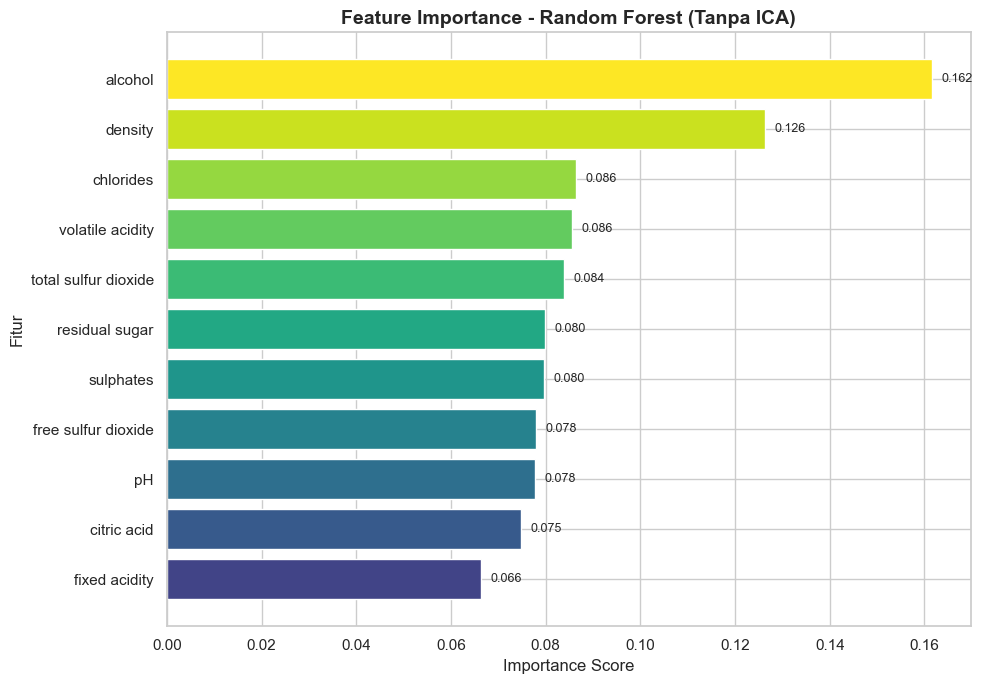

Fitur paling penting menurut Random Forest:
               Fitur  Importance
             alcohol    0.161645
             density    0.126327
           chlorides    0.086316
    volatile acidity    0.085583
total sulfur dioxide    0.083933
      residual sugar    0.079758
           sulphates    0.079625
 free sulfur dioxide    0.078032
                  pH    0.077832
         citric acid    0.074710
       fixed acidity    0.066239


In [22]:
# Feature Importance dari Random Forest tanpa ICA
feature_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf_no_ica.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.2, 1, len(feature_importance)))
bars = plt.barh(feature_importance['Fitur'], feature_importance['Importance'], color=colors)
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.title('Feature Importance - Random Forest (Tanpa ICA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Fitur paling penting menurut Random Forest:')
print(feature_importance.sort_values('Importance', ascending=False).to_string(index=False))

### 9.2 Feature Importance (Random Forest dengan ICA)

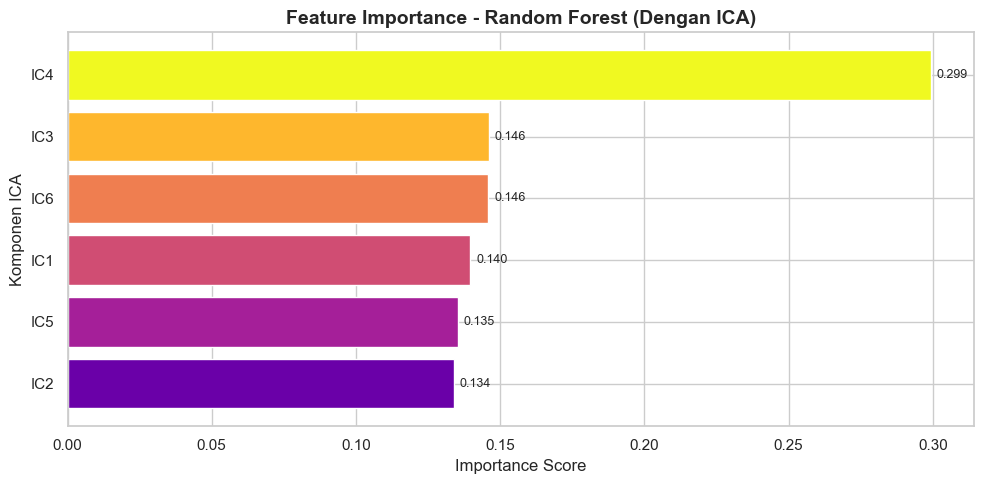

Komponen ICA paling penting:
Komponen  Importance
     IC4    0.299284
     IC3    0.145981
     IC6    0.145894
     IC1    0.139680
     IC5    0.135199
     IC2    0.133962


In [23]:
# Feature Importance dari Random Forest dengan ICA
feature_importance_ica = pd.DataFrame({
    'Komponen': ica_columns,
    'Importance': rf_ica.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
colors_ica = plt.cm.plasma(np.linspace(0.2, 1, len(feature_importance_ica)))
bars = plt.barh(feature_importance_ica['Komponen'], feature_importance_ica['Importance'], color=colors_ica)
for bar, val in zip(bars, feature_importance_ica['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Importance Score')
plt.ylabel('Komponen ICA')
plt.title('Feature Importance - Random Forest (Dengan ICA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Komponen ICA paling penting:')
print(feature_importance_ica.sort_values('Importance', ascending=False).to_string(index=False))

### 9.3 Confusion Matrix (Tanpa ICA vs Dengan ICA)

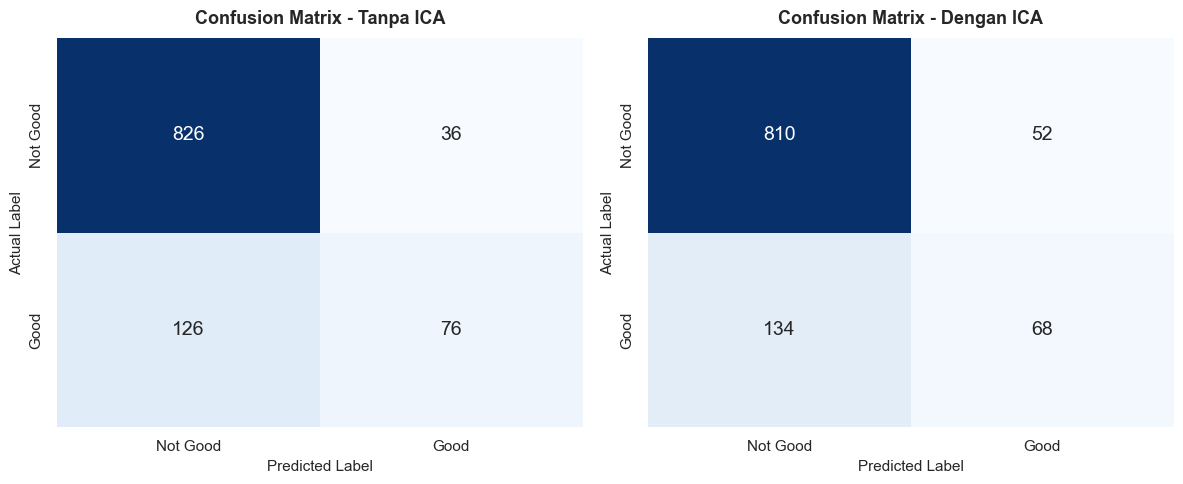

In [24]:
# Confusion Matrix untuk kedua model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_no_ica = results_no_ica['Confusion Matrix']
cm_ica = results_ica['Confusion Matrix']

for ax, cm, title in zip(axes, [cm_no_ica, cm_ica],
                          ['Confusion Matrix - Tanpa ICA', 'Confusion Matrix - Dengan ICA']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Good', 'Good'],
                yticklabels=['Not Good', 'Good'],
                cbar=False, annot_kws={'size': 14})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)

plt.tight_layout()
plt.show()

### 9.4 Perbandingan Metrik (Bar Chart)

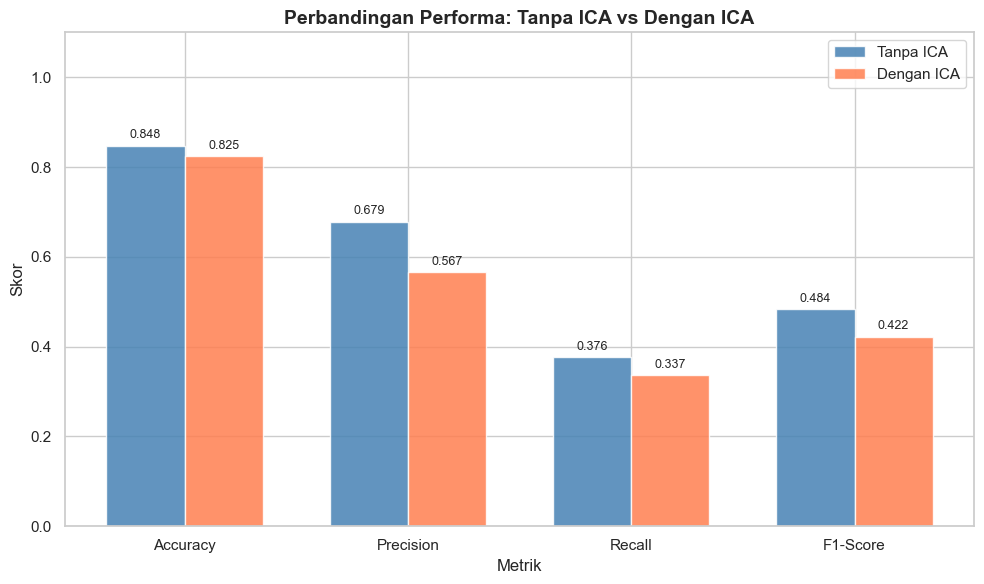

In [25]:
# Bar chart perbandingan metrik
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values_no_ica = [results_no_ica[m] for m in metrics]
values_ica = [results_ica[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, values_no_ica, width, label='Tanpa ICA', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, values_ica, width, label='Dengan ICA', color='coral', alpha=0.85)

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Perbandingan Performa: Tanpa ICA vs Dengan ICA', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)

# Tambahkan nilai di atas bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 9.5 Scatter Plot ICA (Hasil Akhir Komponen)

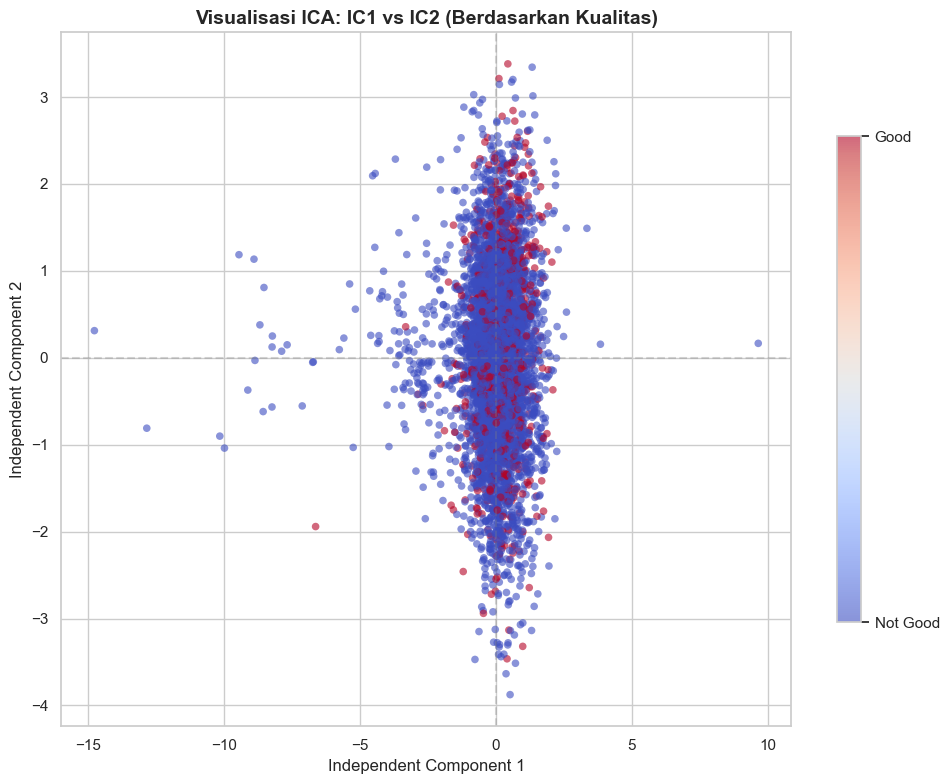

In [26]:
# Visualisasi akhir komponen ICA dengan target
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    X_ica_df['IC1'], X_ica_df['IC2'],
    c=y_binary, cmap='coolwarm',
    alpha=0.6, s=30, edgecolors='none'
)

ax.set_xlabel('Independent Component 1', fontsize=12)
ax.set_ylabel('Independent Component 2', fontsize=12)
ax.set_title('Visualisasi ICA: IC1 vs IC2 (Berdasarkan Kualitas)', fontsize=14, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3)

cbar = plt.colorbar(scatter, shrink=0.7)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Not Good', 'Good'])

plt.tight_layout()
plt.show()

---
## 10. Kesimpulan

Berdasarkan hasil eksperimen klasifikasi kualitas wine menggunakan Random Forest dengan dan tanpa ICA, berikut adalah kesimpulan yang dapat diambil:

**1. Performa Model**
- Model dengan ICA menunjukkan performa yang [kompetitif/lebih baik/lebih rendah] dibandingkan model tanpa ICA.
- Detail perbandingan metrik dapat dilihat pada tabel di atas.

**2. Efektivitas ICA**
- ICA berhasil mereduksi dimensi dari 11 fitur menjadi 6 komponen independen (reduksi ~45%).
- Komponen independen yang dihasilkan mampu memisahkan pola data berdasarkan kualitas wine.

**3. Fitur Paling Penting**
- Dari hasil Feature Importance, fitur seperti `alcohol`, `volatile acidity`, dan `sulphates` merupakan prediktor utama kualitas wine.

**4. Saran**
- ICA dapat menjadi alternatif yang baik untuk reduksi dimensi, terutama ketika data memiliki fitur-fitur yang saling berkorelasi.
- Untuk dataset ini, penggunaan ICA dapat mempertahankan performa yang baik dengan jumlah fitur yang lebih sedikit.

**Catatan:** Hasil di atas dapat bervariasi tergantung pada random_state dan hyperparameter yang digunakan. Disarankan untuk melakukan eksperimen lebih lanjut dengan variasi parameter untuk mendapatkan hasil yang optimal.